In [200]:
import os
import sys
from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns
import infinite
reload(plotting)
reload(pinns)
reload(infinite)
import numpy as np
import sympy as sp
import pickle
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from pinns import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float64)

set_seed(42)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [201]:
model_u, model_k = build_models(
    device=device,
    hidden_layers=4,
    hidden_units=50,
    activation=nn.Tanh(),
) 

(
    X_obs,
    U_obs,
    X_obs_k,
    K_obs,
    X_pde,
    F_pde,
    X,
    Y,
    U,
) = generate_dataset_inf(
    alpha=0.5,
    beta=5.0,
    epsilon=1.0,
    device=device,
)

In [202]:
history = train_dual_network(
    model_u,
    model_k,
    X_obs,
    U_obs,
    X_obs_k,
    K_obs,
    X_pde,
    F_pde,
    adam_lr=1e-3,
    adam_iters=1000,
    lbfgs_iters=2000,
    adaptive_weights=True,
    verbose=True,
)


Training with Adam
Adam     0 | Total=5.231e+01 | ObsU=2.046e-01 | ObsK=6.377e-01 | PDE=5.147e+01
Adam   100 | Total=1.420e+01 | ObsU=3.417e-02 | ObsK=1.068e+00 | PDE=1.310e+01
V      = [0.0518 0.4564 3.6449]
R      = [0.    0.113 1.   ]
ratio  = 70.35
lambda = [ 1.     2.126 11.   ]
Adam   200 | Total=1.109e+01 | ObsU=2.294e-02 | ObsK=6.461e-02 | PDE=9.935e-01
V      = [0.1324 0.0854 1.3635]
R      = [0.037 0.    1.   ]
ratio  = 15.96
lambda = [ 1.367  1.    11.   ]
Adam   300 | Total=5.760e+00 | ObsU=1.776e-01 | ObsK=1.093e-01 | PDE=4.916e-01
Adam   400 | Total=3.514e+00 | ObsU=6.657e-02 | ObsK=1.278e-01 | PDE=2.995e-01
Adam   500 | Total=2.276e+00 | ObsU=1.227e-02 | ObsK=1.382e-01 | PDE=1.928e-01
V      = [0.0055 0.1422 0.1576]
R      = [0.    0.898 1.   ]
ratio  = 28.54
lambda = [ 1.     9.984 11.   ]
Adam   600 | Total=2.819e+00 | ObsU=6.242e-03 | ObsK=1.426e-01 | PDE=1.262e-01
V      = [0.0066 0.0411 0.1158]
R      = [0.    0.316 1.   ]
ratio  = 17.48
lambda = [ 1.    4.16 11.  

In [203]:
with open("results/history_adaptive.pkl", "wb") as f:
    pickle.dump(history, f)

Relative L2 error (u): 7.650e-02
Relative L2 error (k): 6.918e-03


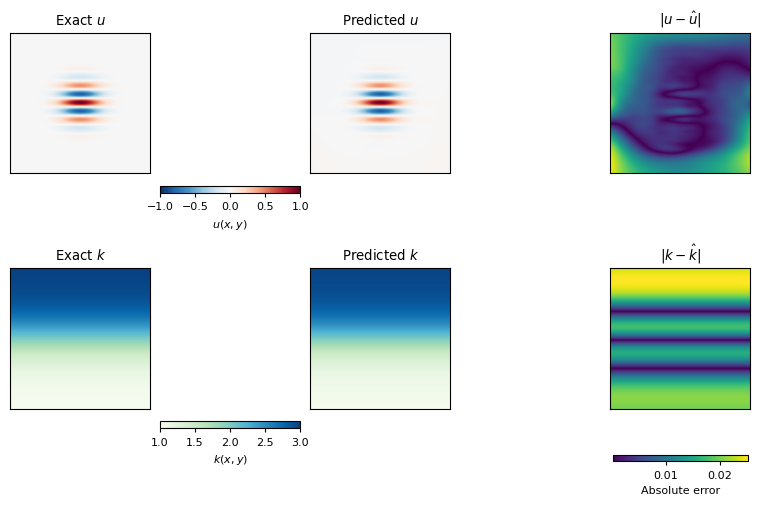

Results saved to: results/infinite_problem_results_20260717_141948.txt


In [204]:
err_u, err_k = evaluate_model_inf(
    model_u,
    model_k,
    analytical_solution_inf,
    coefficient_inf,
    device=device,
    save_results=True,
    verbose=True,
    plot=True
)

In [205]:
with open("results/history_standard.pkl", "rb") as f:
    history_standard = pickle.load(f)

with open("results/history_adaptive.pkl", "rb") as f:
    history_adaptive = pickle.load(f)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


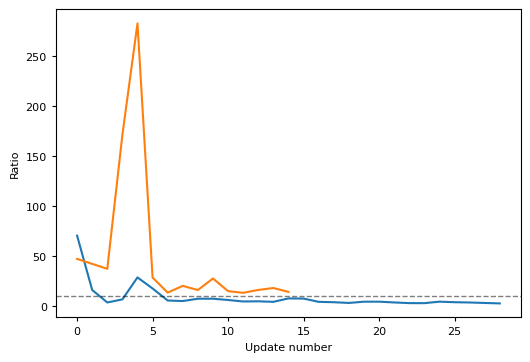

In [206]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(history_adaptive["ratio"])
ax.plot(history_standard["ratio"])
ax.axhline(y=10.0, color="k", linestyle="--", lw=1, alpha=0.5)
ax.set_xlabel("Update number")
ax.set_ylabel(r"Ratio")

ax.legend(frameon=False)

plt.show()

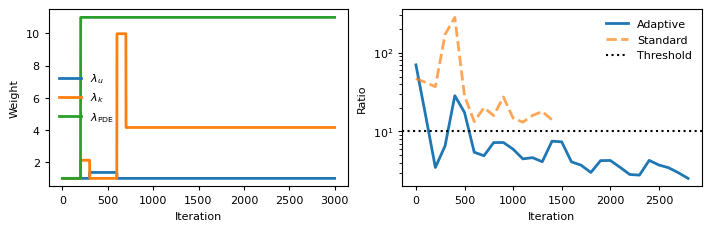

In [208]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(7.0, 2.2),
    constrained_layout=True,
)

# =====================================================
# Left: Adaptive weights
# =====================================================

ax[0].plot(
    history_adaptive["lambda_u"],
    lw=2,
    label=r"$\lambda_u$",
)

ax[0].plot(
    history_adaptive["lambda_k"],
    lw=2,
    label=r"$\lambda_k$",
)

ax[0].plot(
    history_adaptive["lambda_pde"],
    lw=2,
    label=r"$\lambda_{\rm PDE}$",
)

ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Weight")
ax[0].legend(frameon=False, fontsize=8)

# =====================================================
# Right: Ratio comparison
# =====================================================
update_every=100 
ratio_threshold = 10
updates_adaptive = np.arange(len(history_adaptive["ratio"])) * update_every
updates_standard = np.arange(len(history_standard["ratio"])) * update_every

ax[1].plot(
    updates_adaptive,
    history_adaptive["ratio"],
    lw=2,
    label="Adaptive",
)

ax[1].plot(
    updates_standard,
    history_standard["ratio"],
    "--",
    lw=2,
    alpha=0.7,
    label="Standard",
)

ax[1].axhline(
    ratio_threshold,
    color="k",
    ls=":",
    lw=1.5,
    label="Threshold",
)

ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Ratio")
ax[1].set_yscale("log")          # optional but usually better
ax[1].legend(frameon=False, fontsize=8)

plt.savefig(
    "figures/adaptive_weights_ratio.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()